In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
data = {
    "Email": [

        "Congratulations! You have won a free iPhone. Click here now.",
        "Meeting is scheduled tomorrow at 10 AM.",
        "Claim your cash prize immediately.",
        "Project presentation has been postponed.",
        "Limited time offer. Buy now and save money.",
        "Please find the attached report.",
        "Win a lottery worth one million dollars.",
        "Lunch meeting at 1 PM today.",
        "Exclusive deal just for you. Hurry up.",
        "Can we discuss the assignment today?"

    ],

    "Label":[

        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham"

    ]
}

df = pd.DataFrame(data)

print(df)

                                               Email Label
0  Congratulations! You have won a free iPhone. C...  Spam
1            Meeting is scheduled tomorrow at 10 AM.   Ham
2                 Claim your cash prize immediately.  Spam
3           Project presentation has been postponed.   Ham
4        Limited time offer. Buy now and save money.  Spam
5                   Please find the attached report.   Ham
6           Win a lottery worth one million dollars.  Spam
7                       Lunch meeting at 1 PM today.   Ham
8             Exclusive deal just for you. Hurry up.  Spam
9               Can we discuss the assignment today?   Ham


In [5]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Email"] = df["Email"].apply(clean_text)

print(df)

                                               Email Label  \
0  Congratulations! You have won a free iPhone. C...  Spam   
1            Meeting is scheduled tomorrow at 10 AM.   Ham   
2                 Claim your cash prize immediately.  Spam   
3           Project presentation has been postponed.   Ham   
4        Limited time offer. Buy now and save money.  Spam   
5                   Please find the attached report.   Ham   
6           Win a lottery worth one million dollars.  Spam   
7                       Lunch meeting at 1 PM today.   Ham   
8             Exclusive deal just for you. Hurry up.  Spam   
9               Can we discuss the assignment today?   Ham   

                             Clean_Email  
0      congratulations free iphone click  
1             meeting scheduled tomorrow  
2           claim cash prize immediately  
3         project presentation postponed  
4      limited time offer buy save money  
5            please find attached report  
6  win lottery w

In [6]:
df["Target"] = df["Label"].map({
    "Ham":0,
    "Spam":1
})

print(df)

                                               Email Label  \
0  Congratulations! You have won a free iPhone. C...  Spam   
1            Meeting is scheduled tomorrow at 10 AM.   Ham   
2                 Claim your cash prize immediately.  Spam   
3           Project presentation has been postponed.   Ham   
4        Limited time offer. Buy now and save money.  Spam   
5                   Please find the attached report.   Ham   
6           Win a lottery worth one million dollars.  Spam   
7                       Lunch meeting at 1 PM today.   Ham   
8             Exclusive deal just for you. Hurry up.  Spam   
9               Can we discuss the assignment today?   Ham   

                             Clean_Email  Target  
0      congratulations free iphone click       1  
1             meeting scheduled tomorrow       0  
2           claim cash prize immediately       1  
3         project presentation postponed       0  
4      limited time offer buy save money       1  
5          

In [7]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["Clean_Email"])

y = df["Target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [9]:
model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [10]:
prediction = model.predict(X_test)

In [11]:
print("Accuracy")

print(accuracy_score(y_test,prediction))

print()

print(classification_report(y_test,prediction))

print()

print(confusion_matrix(y_test,prediction))

Accuracy
0.5

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


[[1 0]
 [1 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
all_words = " ".join(df["Clean_Email"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top Common Words")

print(word_freq.most_common(10))

Top Common Words
[('meeting', 2), ('today', 2), ('congratulations', 1), ('free', 1), ('iphone', 1), ('click', 1), ('scheduled', 1), ('tomorrow', 1), ('claim', 1), ('cash', 1)]


In [13]:
spam = df[df["Label"]=="Spam"]

spam_words = " ".join(spam["Clean_Email"])

spam_counter = Counter(spam_words.split())

print("Most Frequent Spam Words")

print(spam_counter.most_common(10))

Most Frequent Spam Words
[('congratulations', 1), ('free', 1), ('iphone', 1), ('click', 1), ('claim', 1), ('cash', 1), ('prize', 1), ('immediately', 1), ('limited', 1), ('time', 1)]


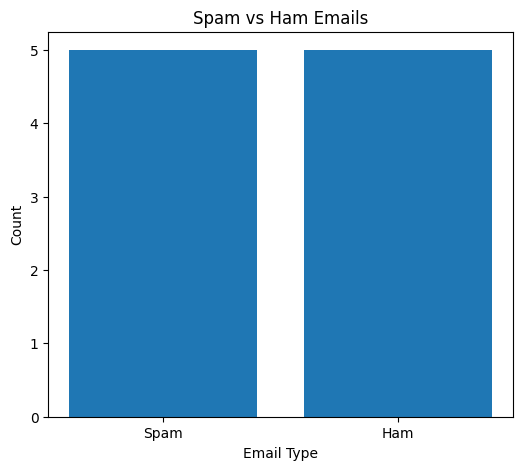

In [14]:
count = df["Label"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(count.index,count.values)

plt.title("Spam vs Ham Emails")

plt.xlabel("Email Type")

plt.ylabel("Count")

plt.show()

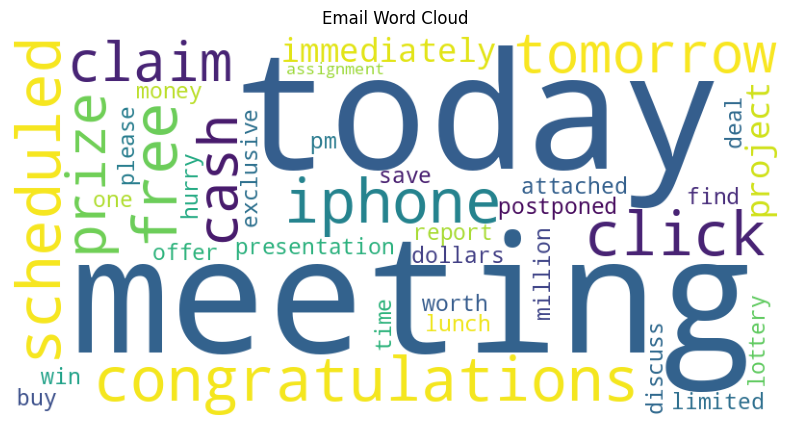

In [15]:
wordcloud = WordCloud(

    width=800,

    height=400,

    background_color="white"

).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Email Word Cloud")

plt.show()

In [16]:
spam_count = len(df[df["Label"]=="Spam"])

ham_count = len(df[df["Label"]=="Ham"])

print("Email Spam Detection Report")
print("---------------------------")

print("Total Emails :",len(df))

print("Spam Emails :",spam_count)

print("Ham Emails :",ham_count)

print()

print("Most Common Spam Words")

for word,count in spam_counter.most_common(5):

    print("-",word)

print()

print("Recommendation")

print("Automatically block suspicious emails containing promotional words such as free, win, prize, lottery, offer, and click.")

Email Spam Detection Report
---------------------------
Total Emails : 10
Spam Emails : 5
Ham Emails : 5

Most Common Spam Words
- congratulations
- free
- iphone
- click
- claim

Recommendation
Automatically block suspicious emails containing promotional words such as free, win, prize, lottery, offer, and click.
